# MTSD 数据集探索

## 目的
分析 MTSD 数据集的特点，包括：
- 类别分布
- 图片和标注的对应关系
- 可视化特定类别的样本

## 数据路径
- 数据集根目录：`/Users/weixianfu/Documents/Datas/mtsd`
- 训练集：`train_full/images` 和 `train_full/labels`
- 验证集：`val/images` 和 `val/labels`
- 类别文件：`classes.json`


In [31]:
import json
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np


In [32]:
# Configure data paths
DATA_ROOT = Path("/Users/weixianfu/Documents/Datas/mtsd")
CLASSES_FILE = DATA_ROOT / "classes.json"

# Select dataset split to analyze (train_full, train_partial, val, sample)
DATASET_SPLIT = "train_full"  # Options: "val", "train_partial", "sample"

IMAGES_DIR = DATA_ROOT / DATASET_SPLIT / "images"
LABELS_DIR = DATA_ROOT / DATASET_SPLIT / "labels"


In [33]:
# Load class information
with open(CLASSES_FILE, 'r', encoding='utf-8') as f:
    classes_data = json.load(f)
    
class_names = classes_data.get('names', [])
print(f"Total classes: {len(class_names)}")
print(f"First 10 classes: {class_names[:10]}")


Total classes: 401
First 10 classes: ['warning--traffic-merges-right--g1', 'warning--added-lane-right--g1', 'warning--playground--g1', 'other-sign', 'regulatory--no-stopping--g15', 'regulatory--priority-road--g4', 'warning--pedestrian-stumble-train--g1', 'regulatory--maximum-speed-limit-45--g3', 'regulatory--stop--g1', 'warning--railroad-crossing--g1']


In [34]:
# Get all image files
image_files = list(IMAGES_DIR.glob("*.jpg")) 
print(f"Total images: {len(image_files)}")

Total images: 36589


In [35]:
# Filter images containing a specific class
def find_images_with_class(target_class_id: int) -> list:
    """
    Find all images containing the specified class
    
    Parameters:
    -----------
    target_class_id : int
        Target class ID
        
    Returns:
    -------
    list[Path]
        List of image paths containing this class
    """
    matching_images = []
    
    for image_file in image_files:
        label_file = LABELS_DIR / f"{image_file.stem}.txt"
        
        if not label_file.exists():
            continue
            
        # Read label file
        with open(label_file, 'r') as f:
            lines = f.readlines()
            
        # Check if contains target class
        for line in lines:
            parts = line.strip().split()
            if parts and int(parts[0]) == target_class_id:
                matching_images.append(image_file)
                break
    
    return matching_images


In [36]:
# Select class to view (modify the class name here)
target_class_name = "regulatory--stop--g1"  # Change to the class you want to view

# Find class ID
try:
    target_class_id = class_names.index(target_class_name)
    print(f"Class '{target_class_name}' ID: {target_class_id}")
except ValueError:
    print(f"Class not found: {target_class_name}")
    print(f"Available class examples: {class_names[:5]}")
    target_class_id = 0  # Default to first class


Class 'regulatory--stop--g1' ID: 8


In [37]:
# Find all images containing this class
matching_images = find_images_with_class(target_class_id)
print(f"Images containing class '{class_names[target_class_id]}': {len(matching_images)}")

if len(matching_images) == 0:
    print("No images found with this class. Please check class ID or dataset path.")


Images containing class 'regulatory--stop--g1': 1010


In [38]:
# Randomly select an image
if matching_images:
    selected_image = random.choice(matching_images)
    print(f"Selected image: {selected_image.name}")
    
    # Read image
    image = Image.open(selected_image)
    img_width, img_height = image.size
    print(f"Image size: {img_width} x {img_height}")
    
    # Read corresponding label file
    label_file = LABELS_DIR / f"{selected_image.stem}.txt"
    
    boxes = []
    class_ids = []
    box_sizes = []  # Store size of each box
    
    if label_file.exists():
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])
                    
                    # Convert to absolute coordinates (x1, y1, x2, y2)
                    x1 = (x_center - width / 2) * img_width
                    y1 = (y_center - height / 2) * img_height
                    x2 = (x_center + width / 2) * img_width
                    y2 = (y_center + height / 2) * img_height
                    
                    # Calculate box width and height (pixels)
                    box_width = x2 - x1
                    box_height = y2 - y1
                    
                    boxes.append((x1, y1, x2, y2))
                    class_ids.append(class_id)
                    box_sizes.append((box_width, box_height))
    
    print(f"\nDetected objects: {len(boxes)}")
    print(f"\nBox details:")
    for i, (class_id, (w, h)) in enumerate(zip(class_ids, box_sizes)):
        class_name = class_names[class_id]
        print(f"  Box {i+1}: {class_name} (ID: {class_id})")
        print(f"    Size: {w:.1f} x {h:.1f} pixels")
        print(f"    Coordinates: ({boxes[i][0]:.1f}, {boxes[i][1]:.1f}) -> ({boxes[i][2]:.1f}, {boxes[i][3]:.1f})")
        print()


Selected image: fully_train_OX-npt3RpByin_Ess7YdYQ.jpg
Image size: 4032 x 3024

Detected objects: 3

Box details:
  Box 1: regulatory--maximum-speed-limit-30--g1 (ID: 85)
    Size: 30.5 x 31.0 pixels
    Coordinates: (2239.5, 1833.9) -> (2270.0, 1864.9)

  Box 2: regulatory--no-left-turn--g1 (ID: 175)
    Size: 109.3 x 113.0 pixels
    Coordinates: (2061.3, 1737.2) -> (2170.5, 1850.1)

  Box 3: regulatory--stop--g1 (ID: 8)
    Size: 32.5 x 104.8 pixels
    Coordinates: (1295.4, 1860.5) -> (1327.9, 1965.3)



Saved original image to: original_image.png


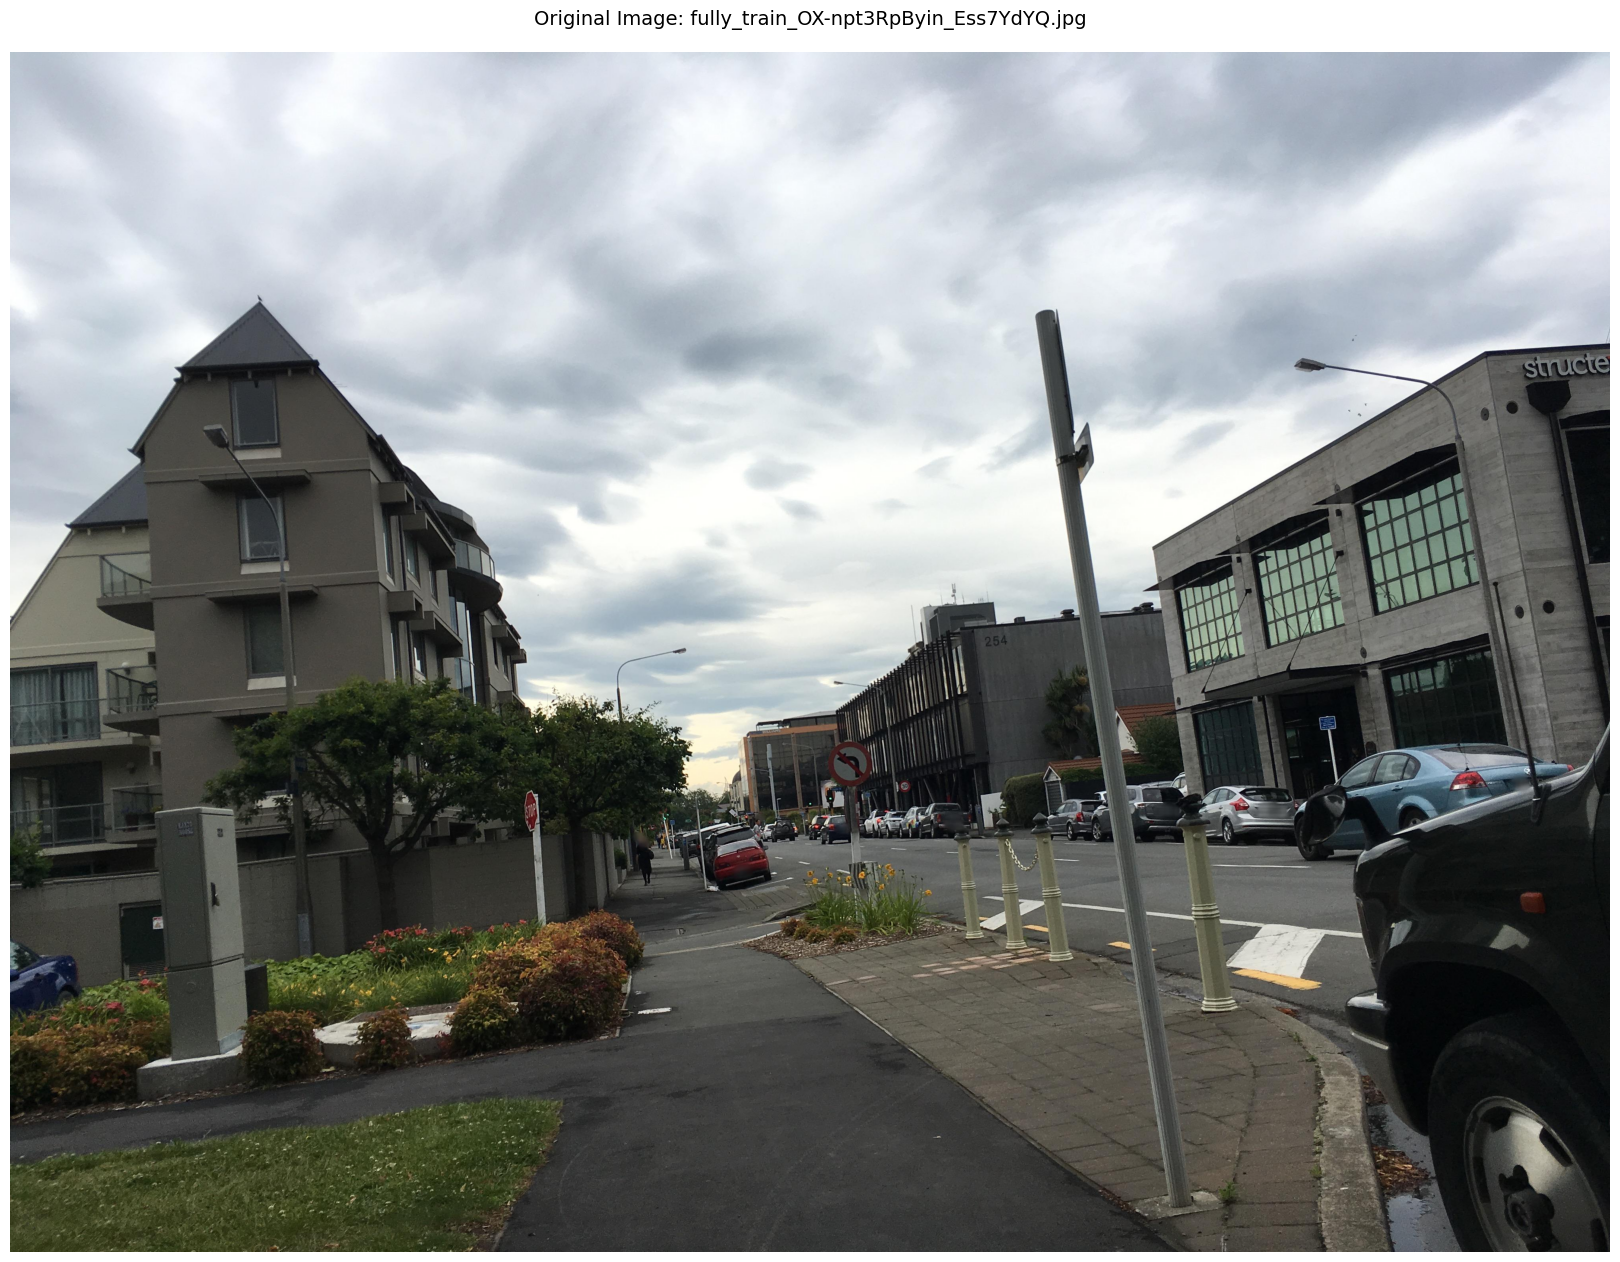

Saved annotated image to: annotated_image.png


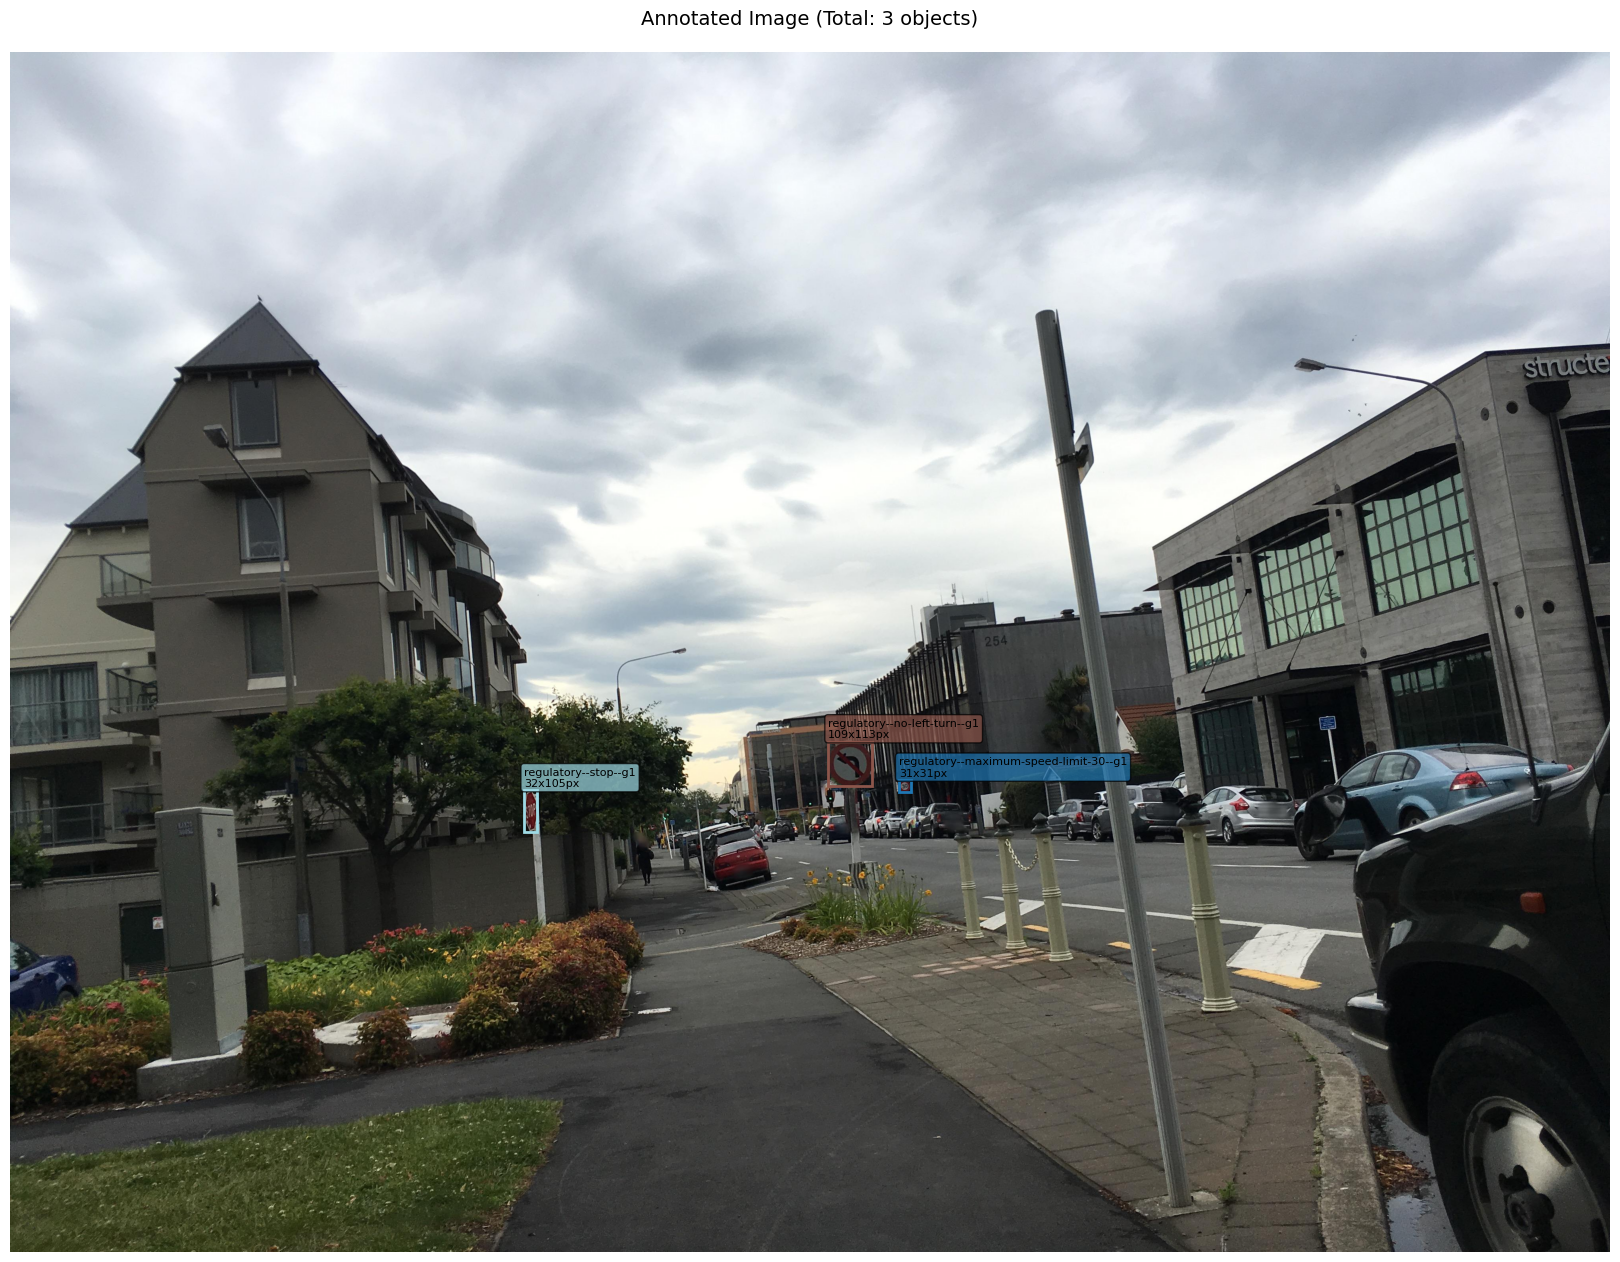

In [39]:
# Display and save original and annotated images
if matching_images:
    dpi = 100
    max_display_width = 16
    max_display_height = 12
    
    fig_width = img_width / dpi
    fig_height = img_height / dpi
    
    if fig_width > max_display_width:
        scale = max_display_width / fig_width
        fig_width = max_display_width
        fig_height = fig_height * scale
    if fig_height > max_display_height:
        scale = max_display_height / fig_height
        fig_height = max_display_height
        fig_width = fig_width * scale
    
    # Original image
    fig1 = plt.figure(figsize=(fig_width, fig_height), dpi=dpi)
    ax1 = fig1.add_axes([0, 0, 1, 1])
    ax1.imshow(image)
    ax1.set_title(f"Original Image: {selected_image.name}", fontsize=14, pad=20)
    ax1.axis('off')
    
    original_path = Path("original_image.png")
    fig1.savefig(original_path, dpi=dpi, bbox_inches='tight', pad_inches=0)
    print(f"Saved original image to: {original_path}")
    plt.show()
    
    # Annotated image
    fig2 = plt.figure(figsize=(fig_width, fig_height), dpi=dpi)
    ax2 = fig2.add_axes([0, 0, 1, 1])
    ax2.imshow(image)
    ax2.set_title(f"Annotated Image (Total: {len(boxes)} objects)", fontsize=14, pad=20)
    ax2.axis('off')
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(boxes)))
    for i, ((x1, y1, x2, y2), class_id, (w, h)) in enumerate(zip(boxes, class_ids, box_sizes)):
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor=colors[i], facecolor='none')
        ax2.add_patch(rect)
        class_name = class_names[class_id]
        label_text = f"{class_name}\n{w:.0f}x{h:.0f}px"
        ax2.text(x1, y1 - 5, label_text, bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.7), fontsize=8, color='black', verticalalignment='bottom')
    
    annotated_path = Path("annotated_image.png")
    fig2.savefig(annotated_path, dpi=dpi, bbox_inches='tight', pad_inches=0)
    print(f"Saved annotated image to: {annotated_path}")
    plt.show()


In [40]:
# Delete saved images
Path("original_image.png").unlink()
Path("annotated_image.png").unlink()

# 图片切分验证

## 目的
验证图片切分功能，将大图片（4K: 4032x3024）切分为 1280x1280 的切片，重叠率 20%。
这样可以保留小目标（22px）的特征，避免直接 resize 导致的特征丢失。


In [41]:
import sys
sys.path.append('..')

from src.io.slicer import slice_image
import cv2

In [42]:
# 使用之前选中的图片进行切分测试
if matching_images:
    test_image_path = str(selected_image)
    
    slices = slice_image(test_image_path, slice_size=1280, overlap=0.2)
    
    print(f"Original image size: {img_width} x {img_height}")
    print(f"Number of slices: {len(slices)}")
    print(f"\nSlice details:")
    for i, (slice_img, (x1, y1, x2, y2)) in enumerate(slices):
        print(f"  Slice {i+1}: position ({x1}, {y1}) -> ({x2}, {y2}), size {slice_img.shape[1]}x{slice_img.shape[0]}")


Original image size: 4032 x 3024
Number of slices: 12

Slice details:
  Slice 1: position (0, 0) -> (1280, 1280), size 1280x1280
  Slice 2: position (1024, 0) -> (2304, 1280), size 1280x1280
  Slice 3: position (2048, 0) -> (3328, 1280), size 1280x1280
  Slice 4: position (2752, 0) -> (4032, 1280), size 1280x1280
  Slice 5: position (0, 1024) -> (1280, 2304), size 1280x1280
  Slice 6: position (1024, 1024) -> (2304, 2304), size 1280x1280
  Slice 7: position (2048, 1024) -> (3328, 2304), size 1280x1280
  Slice 8: position (2752, 1024) -> (4032, 2304), size 1280x1280
  Slice 9: position (0, 1744) -> (1280, 3024), size 1280x1280
  Slice 10: position (1024, 1744) -> (2304, 3024), size 1280x1280
  Slice 11: position (2048, 1744) -> (3328, 3024), size 1280x1280
  Slice 12: position (2752, 1744) -> (4032, 3024), size 1280x1280


In [43]:
1280*0.8+1280

2304.0

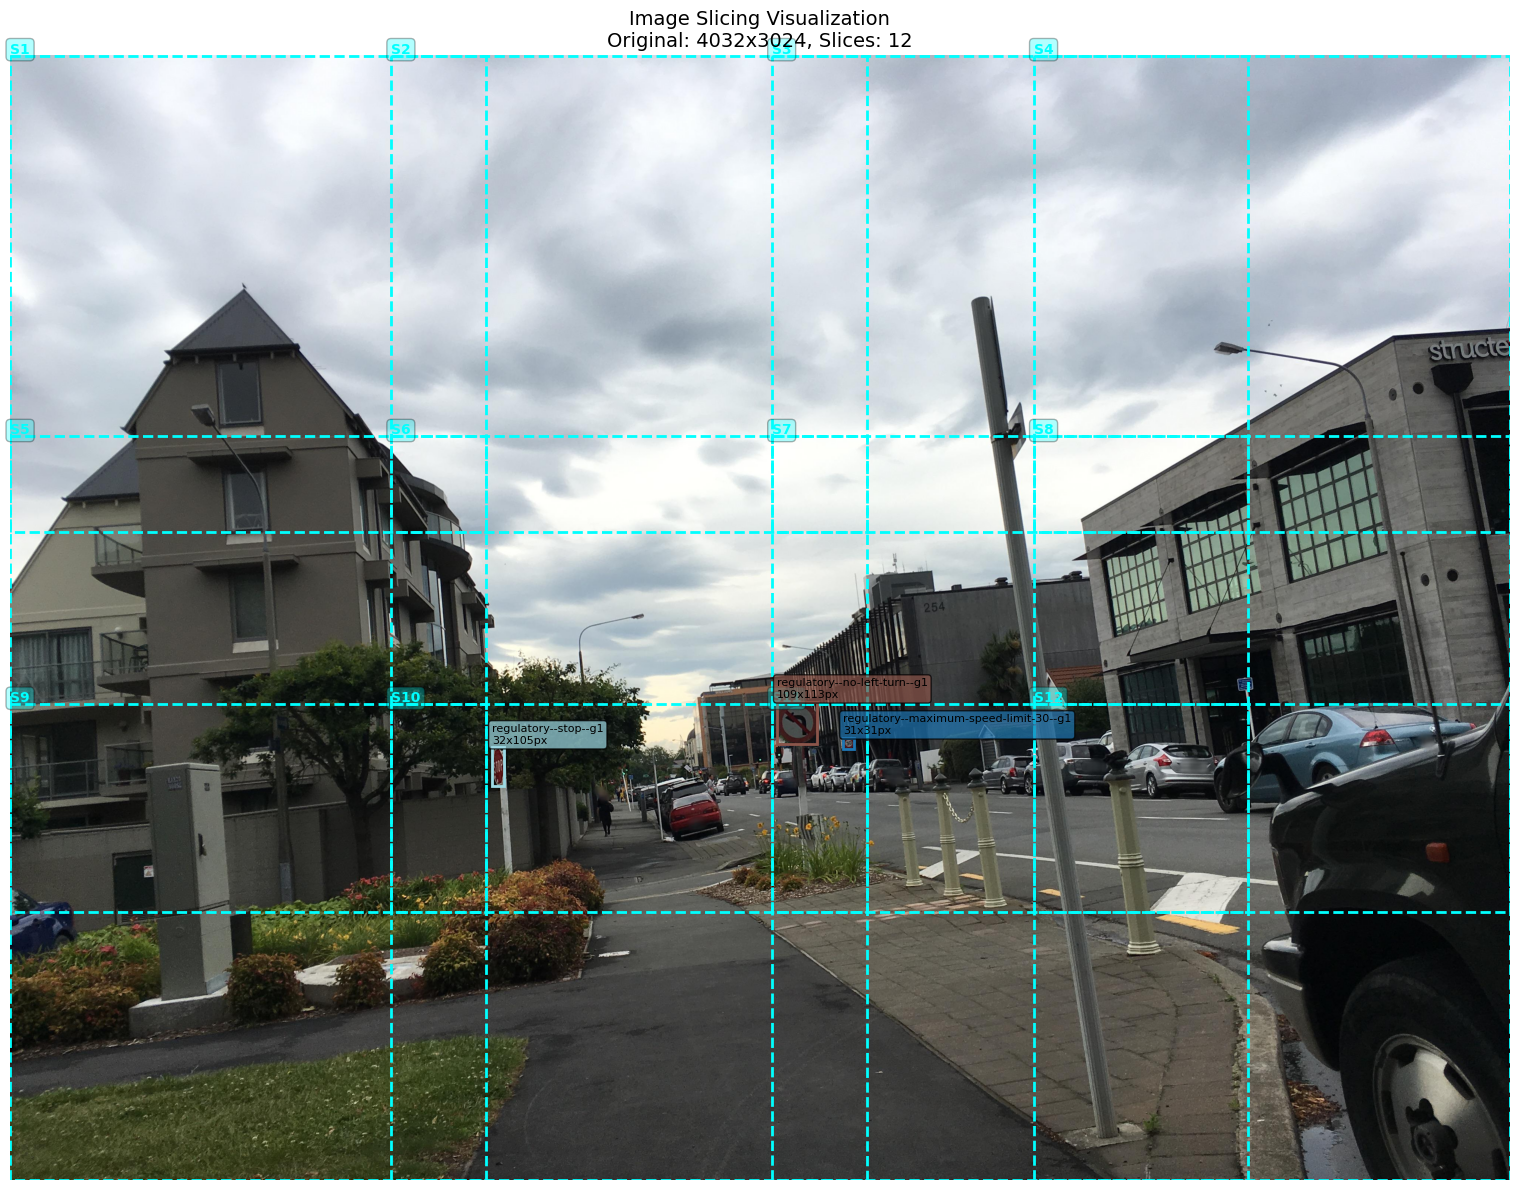


Legend:
  Cyan dashed lines: Slice boundaries (12 slices)
  Colored boxes: Original bounding boxes (3 objects)


In [44]:
# 可视化切分结果：在原图上绘制切分边界和 bbox
if matching_images and slices:
    img_cv = cv2.imread(str(selected_image))
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    
    fig, ax = plt.subplots(1, 1, figsize=(16, 12))
    ax.imshow(img_rgb)
    ax.set_title(f"Image Slicing Visualization\nOriginal: {img_width}x{img_height}, Slices: {len(slices)}", fontsize=14)
    
    # 绘制切分边界
    for i, (_, (x1, y1, x2, y2)) in enumerate(slices):
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                linewidth=2, edgecolor='cyan', facecolor='none', linestyle='--')
        ax.add_patch(rect)
        ax.text(x1, y1-5, f'S{i+1}', color='cyan', fontsize=10, weight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='cyan', alpha=0.3))
    
    # 绘制原始 bbox
    colors = plt.cm.tab20(np.linspace(0, 1, len(boxes)))
    for i, ((bx1, by1, bx2, by2), class_id, (w, h)) in enumerate(zip(boxes, class_ids, box_sizes)):
        rect = patches.Rectangle((bx1, by1), bx2-bx1, by2-by1, 
                                linewidth=2, edgecolor=colors[i], facecolor='none')
        ax.add_patch(rect)
        class_name = class_names[class_id]
        ax.text(bx1, by1-5, f"{class_name}\n{w:.0f}x{h:.0f}px", 
               bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.7), 
               fontsize=8, color='black', verticalalignment='bottom')
    
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"\nLegend:")
    print(f"  Cyan dashed lines: Slice boundaries ({len(slices)} slices)")
    print(f"  Colored boxes: Original bounding boxes ({len(boxes)} objects)")


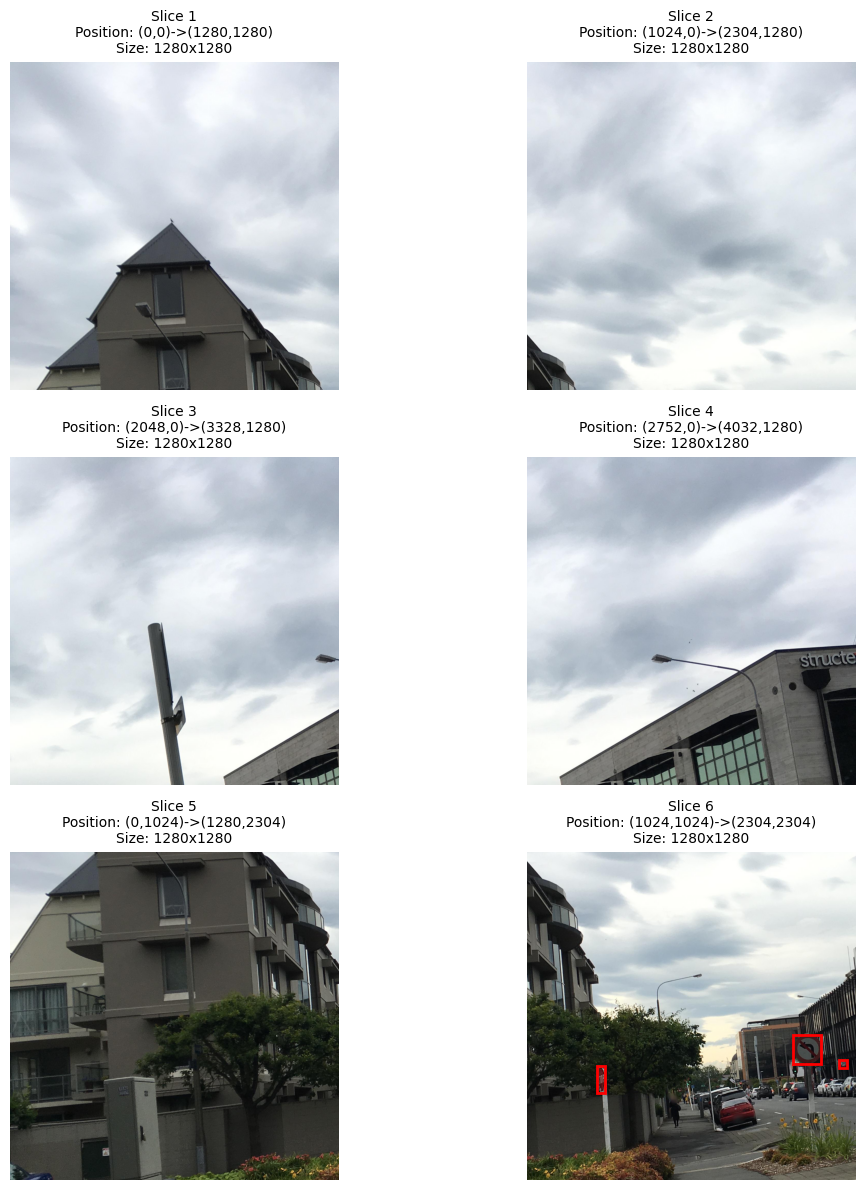

Displayed first 6 slices out of 12 total slices.


In [45]:
# 显示前几个切片的详细内容
if matching_images and slices:
    num_display = min(6, len(slices))
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    axes = axes.flatten()
    
    for idx in range(num_display):
        slice_img, (x1, y1, x2, y2) = slices[idx]
        slice_rgb = cv2.cvtColor(slice_img, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(slice_rgb)
        axes[idx].set_title(f"Slice {idx+1}\nPosition: ({x1},{y1})->({x2},{y2})\nSize: {slice_img.shape[1]}x{slice_img.shape[0]}", 
                           fontsize=10)
        axes[idx].axis('off')
        
        # 在切片上绘制包含的 bbox（如果有）
        for i, ((bx1, by1, bx2, by2), class_id) in enumerate(zip(boxes, class_ids)):
            # 检查 bbox 是否与切片重叠
            if not (bx2 < x1 or bx1 > x2 or by2 < y1 or by1 > y2):
                # 计算 bbox 在切片中的相对坐标
                rel_x1 = max(0, bx1 - x1)
                rel_y1 = max(0, by1 - y1)
                rel_x2 = min(slice_img.shape[1], bx2 - x1)
                rel_y2 = min(slice_img.shape[0], by2 - y1)
                
                if rel_x2 > rel_x1 and rel_y2 > rel_y1:
                    rect = patches.Rectangle((rel_x1, rel_y1), rel_x2-rel_x1, rel_y2-rel_y1,
                                           linewidth=2, edgecolor='red', facecolor='none')
                    axes[idx].add_patch(rect)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Displayed first {num_display} slices out of {len(slices)} total slices.")
